# Sentiment Analysis of News Headlines Across Major Outlets
### STA 141B Final Project

##### Important Note: Web scraping cells were ran locally to collect data. The resulting cleaned dataset is available in this repository as a CSV file and is loaded directly in the cell below. Scraping cells do not need to be re-run to reproduce the analysis.

In [7]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd
import re
from textblob import TextBlob


headers = {'User-Agent': 'STA141B Student Project Scraper'}

def clean_text(text):
    #data cleaning (removing live updates, new episode tags, and non-alphanumeric characters)
    text = re.sub(r'(Live Updates|New episode)+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def scrape_news(url, source_name):
    print(f"Scraping {source_name}...")
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')

    headlines = []

    # CNN has a unique structure for headlines, so we handle it separately
    if source_name == "CNN":
        tags = soup.find_all('span', class_='container__headline-text')
    else:
        tags = soup.find_all(['h1', 'h2', 'h3'])

    for tag in tags:
        cleaned = clean_text(tag.get_text())
        if len(cleaned) > 15:
            headlines.append({'Headline': cleaned, 'Source': source_name})

    time.sleep(1)
    return headlines
sources = {
    "BBC": "https://www.bbc.com/news",
    "ABC": "https://abcnews.go.com",
    "CNN": "https://www.cnn.com",
    "Fox": "https://www.foxnews.com",
    "AP": "https://apnews.com",
    "NBC": "https://www.nbcnews.com" 
}

all_headlines = []
for name, url in sources.items():
    all_headlines.extend(scrape_news(url, name))

df = pd.DataFrame(all_headlines)

df.head()

Scraping BBC...


ConnectionError: HTTPSConnectionPool(host='www.bbc.com', port=443): Max retries exceeded with url: /news (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x17c4a6d80>: Failed to resolve 'www.bbc.com' ([Errno 8] nodename nor servname provided, or not known)"))

### URL Cleaning/Data Cleaning

In [6]:
# URL Cleaning
def normalize_url(base_url, link):
    if link is None:
        return None

    link = link.strip()
    if link.startswith("http"):
        return link

    if link.startswith("/"):
        base = re.match(r"^https?://[^/]+", base_url).group(0)
        return base + link

    return link

base_by_source = {name: url for name, url in sources.items()}

df["URL"] = df.apply(
    lambda row: normalize_url(base_by_source.get(row["Source"], ""), row.get("URL")),
    axis=1
)

NameError: name 'df' is not defined

In [5]:
# feature engineering(focus on words and punctuation)
def headline_features(text):

    words = re.findall(r"[A-Za-z']+", text.lower())

    word_count = len(words)
    unique_words = len(set(words))

    return {
        "word_count": word_count,
        "unique_words": unique_words,
        "type_token_ratio": unique_words / word_count if word_count > 0 else 0,
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "comma_count": text.count(",")
    }
feature_df = df["Headline"].apply(headline_features).apply(pd.Series)

df = pd.concat([df, feature_df], axis=1)

NameError: name 'df' is not defined

In [4]:
#sentiment analysis using TextBlob
def get_sentiment(row):
    blob = TextBlob(row['Headline'])
    # Polarity: [-1, 1], Subjectivity: [0, 1]
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

# applying the nlp transformations
df[['Polarity', 'Subjectivity']] = df.apply(get_sentiment, axis=1)

df.to_csv('final_project_data.csv', index=False)

NameError: name 'df' is not defined

In [8]:
df = pd.read_csv('final_project_data.csv')

### SQL: Storing and Querying Data with SQLite

In [9]:
import sqlite3

conn = sqlite3.connect('news_headlines.db')

#storing full dataframe in SQL table
df.to_sql('headlines', conn, if_exists='replace', index=False)
print(f'Inserted {len(df)} rows into headlines table')


Inserted 636 rows into headlines table


In [10]:
print("Average Sentiment based on Source:")
result = pd.read_sql_query('''
    SELECT source,
           ROUND(AVG(polarity), 4) AS avg_polarity,
           ROUND(AVG(subjectivity), 4) AS avg_subjectivity,
           COUNT(*) AS headline_count
    FROM headlines
    GROUP BY source
    ORDER BY avg_polarity DESC
''', conn)
print(result)

print("Sources with most negative headlines:")
result2 = pd.read_sql_query('''
    SELECT source, headline, ROUND(polarity, 4) AS polarity
    FROM headlines
    WHERE polarity < 0
    ORDER BY polarity ASC
    LIMIT 5
''', conn)
print(result2)

print("Average Word Count and Longest Headline by Source:")
result3 = pd.read_sql_query('''
    SELECT source,
           ROUND(AVG(word_count), 2) AS avg_word_count,
           MAX(word_count) AS longest_headline
    FROM headlines
    GROUP BY source
    ORDER BY avg_word_count DESC
''', conn)
print(result3)

conn.close()


Average Sentiment based on Source:
  Source  avg_polarity  avg_subjectivity  headline_count
0    ABC        0.0798            0.2822             148
1     AP        0.0455            0.2667             113
2    Fox        0.0324            0.3018             203
3    BBC        0.0229            0.2478              54
4    NBC        0.0169            0.3140              70
5    CNN        0.0050            0.1867              48
Sources with most negative headlines:
  Source                                           Headline  polarity
0    BBC  My identity was stolen and someone is using it...    -1.000
1    Fox  Ryan Clark Calls Trump Admin 'Illegitimate' An...    -1.000
2    Fox  Sewage spill in Potomac River crushes oyster i...    -1.000
3    Fox  Ex-Iranian women's soccer player reveals regim...    -0.875
4    Fox  Violent tornadoes tear 'catastrophic' path acr...    -0.800
Average Word Count and Longest Headline by Source:
  Source  avg_word_count  longest_headline
0     AP      

In [11]:
# summary stats
sentiment_summary = df.groupby('Source')[['Polarity', 'Subjectivity']].agg(
    Mean_Polarity=('Polarity', 'mean'),
    Std_Polarity=('Polarity', 'std'),
    Mean_Subjectivity=('Subjectivity', 'mean'),
    Std_Subjectivity=('Subjectivity', 'std'),
    Count=('Polarity', 'count')
).round(4)

print(sentiment_summary.sort_values('Mean_Subjectivity'))

        Mean_Polarity  Std_Polarity  Mean_Subjectivity  Std_Subjectivity  \
Source                                                                     
CNN            0.0050        0.1577             0.1867            0.2712   
BBC            0.0229        0.2473             0.2478            0.3101   
AP             0.0455        0.2082             0.2667            0.2929   
ABC            0.0798        0.2463             0.2822            0.3046   
Fox            0.0324        0.2515             0.3018            0.2984   
NBC            0.0169        0.2287             0.3140            0.2726   

        Count  
Source         
CNN        48  
BBC        54  
AP        113  
ABC       148  
Fox       203  
NBC        70  


In [12]:
# most reliable/ neutral outlet
# "neutrality score" = distance from zero polarity + subjectivity (lower = more neutral)
sentiment_summary['Neutrality_Score'] = (
    sentiment_summary['Mean_Polarity'].abs() + sentiment_summary['Mean_Subjectivity']
)

print("Neutrality Ranking (lower = more neutral)")
print(sentiment_summary[['Mean_Polarity', 'Mean_Subjectivity', 'Count', 'Neutrality_Score']]
      .sort_values('Neutrality_Score'))

most_neutral = sentiment_summary['Neutrality_Score'].idxmin()
print(f"\nMost neutral outlet: {most_neutral}")

Neutrality Ranking (lower = more neutral)
        Mean_Polarity  Mean_Subjectivity  Count  Neutrality_Score
Source                                                           
CNN            0.0050             0.1867     48            0.1917
BBC            0.0229             0.2478     54            0.2707
AP             0.0455             0.2667    113            0.3122
NBC            0.0169             0.3140     70            0.3309
Fox            0.0324             0.3018    203            0.3342
ABC            0.0798             0.2822    148            0.3620

Most neutral outlet: CNN


In [13]:
df.groupby('Source')['Polarity'].std()

Source
ABC    0.246292
AP     0.208225
BBC    0.247320
CNN    0.157652
Fox    0.251458
NBC    0.228703
Name: Polarity, dtype: float64

In [14]:
df.groupby('Source')['Subjectivity'].std()

Source
ABC    0.304558
AP     0.292937
BBC    0.310146
CNN    0.271174
Fox    0.298351
NBC    0.272552
Name: Subjectivity, dtype: float64

### Kruskal-Wallis Test

In [16]:
#checking statistical significance
from scipy import stats

groups = [group['Polarity'].values for _, group in df.groupby('Source')]
stat_pol, p_pol = stats.kruskal(*groups)

groups_sub = [group['Subjectivity'].values for _, group in df.groupby('Source')]
stat_sub, p_sub = stats.kruskal(*groups_sub)

print("Results")
#to see if there are significant differences in polarity and subjectivity across news sources
print(f"Polarity: H = {stat_pol:.3f},  p = {p_pol:.4f}  {'significant (p<0.05)' if p_pol < 0.05 else 'not significant'}")
print(f"Subjectivity: H = {stat_sub:.3f},  p = {p_sub:.4f}  {'significant (p<0.05)' if p_sub < 0.05 else 'not significant'}")

Results
Polarity: H = 3.744,  p = 0.5868  not significant
Subjectivity: H = 9.680,  p = 0.0848  not significant


### Additional Dunn's post-hoc test

By using the Dunn's post-hoc test with Bonferroni connection, we hope to identify which specific outlet pairs are significantly different

In [ ]:
# importing Dunn's post-hoc test
import scikit_posthocs as sp

print("Polarity")
dunn_pol = sp.posthoc_dunn(df, val_col='Polarity', group_col='Source', p_adjust='bonferroni')
print(dunn_pol.round(4))

print("Subjectivity")
dunn_sub = sp.posthoc_dunn(df, val_col='Subjectivity', group_col='Source', p_adjust='bonferroni')
print(dunn_sub.round(4))

#highlight specific pairs that are significantly different in polarity
print("Significant Polarity Pairs (p < 0.05):")
sig_pairs = [(i, j) for i in dunn_pol.index for j in dunn_pol.columns
             if i < j and dunn_pol.loc[i, j] < 0.05]
for a, b in sig_pairs:
    print(f"  {a} vs {b}: p = {dunn_pol.loc[a, b]:.4f}")


Polarity
     ABC   AP  BBC  CNN  Fox  NBC
ABC  1.0  1.0  1.0  1.0  1.0  1.0
AP   1.0  1.0  1.0  1.0  1.0  1.0
BBC  1.0  1.0  1.0  1.0  1.0  1.0
CNN  1.0  1.0  1.0  1.0  1.0  1.0
Fox  1.0  1.0  1.0  1.0  1.0  1.0
NBC  1.0  1.0  1.0  1.0  1.0  1.0
Subjectivity
        ABC   AP  BBC     CNN     Fox     NBC
ABC  1.0000  1.0  1.0  0.9156  1.0000  1.0000
AP   1.0000  1.0  1.0  1.0000  1.0000  1.0000
BBC  1.0000  1.0  1.0  1.0000  1.0000  1.0000
CNN  0.9156  1.0  1.0  1.0000  0.1942  0.1054
Fox  1.0000  1.0  1.0  0.1942  1.0000  1.0000
NBC  1.0000  1.0  1.0  0.1054  1.0000  1.0000
Significant Polarity Pairs (p < 0.05)


No outlet pairs showed statistically significant differences after Bonferroni correction, suggesting that while aggregate differences exist across all six outlets (Kruskal-Wallis), no single pair of outlets is dramatically different in tone. CNN shows the most distinct subjectivity pattern, approaching but not reaching significance against NBC and Fox.

### TF-IDF Analysis: Most Distinctive Words Per Outlet

In [18]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

custom_stop_words = ['say', 'says', 'said', 'reveals', 'reveal', 'revealed',
                     'report', 'reports', 'reported', 'show', 'shows', 'shown',
                     'new', 'one', 'two', 'first', 'year', 'years', 'week',
                     'monday', 'tuesday', 'wednesday', 'thursday', 'friday',
                     'saturday', 'sunday', 'using', 'use', 'used', 'make', 'makes', 
                     'made', 'go', 'goes', 'went', 'get', 'gets', 'got', 'see', 'sees', 'saw', 
                     'know', 'knows', 'knew', 'think', 'thinks', 'thought', 'look', 'looks', 'looked', 'find', 'finds',]
combined_stop_words = list(ENGLISH_STOP_WORDS) + custom_stop_words

#combining all headlines per source into one document each
source_docs = df.groupby('Source')['Headline'].apply(lambda x: ' '.join(x)).reset_index()

#fitting TF-IDF treating each source as one document
vectorizer = TfidfVectorizer(stop_words=combined_stop_words, max_features=500)
tfidf_matrix = vectorizer.fit_transform(source_docs['Headline'])
feature_names = vectorizer.get_feature_names_out()

#extracting top words for each source based on the TF-IDF scores
def top_words(source_name, tfidf_row, feature_names, n=10):
    scores = tfidf_row.toarray().flatten()
    top_indices = scores.argsort()[::-1][:n]
    return [(feature_names[i], round(scores[i], 4)) for i in top_indices]

for i, row in source_docs.iterrows():
    source = row['Source']
    words = top_words(source, tfidf_matrix[i], feature_names)
    print(f'\n{source}:')
    for word, score in words:
        print(f'  {word}: {score}')



ABC:
  oscars: 0.3483
  iran: 0.3219
  2026: 0.2869
  war: 0.1533
  woman: 0.1416
  official: 0.1381
  1st: 0.1381
  attacks: 0.1195
  oscar: 0.1133
  shop: 0.1133

AP:
  iran: 0.3119
  people: 0.2594
  lawmakers: 0.1921
  ohio: 0.1874
  trump: 0.1663
  court: 0.1536
  president: 0.1536
  war: 0.1456
  southern: 0.1405
  ap: 0.1297

BBC:
  politician: 0.2455
  bbc: 0.2013
  iran: 0.1816
  war: 0.1816
  iranian: 0.1816
  women: 0.17
  arrives: 0.1637
  recruit: 0.1637
  indian: 0.1637
  remarks: 0.1637

CNN:
  iran: 0.4253
  kuwait: 0.2613
  trump: 0.232
  major: 0.155
  war: 0.1546
  iranian: 0.1546
  dad: 0.1428
  chilling: 0.1428
  boom: 0.1428
  turned: 0.1428

Fox:
  fox: 0.2022
  trump: 0.197
  america: 0.1902
  march: 0.1618
  mamdani: 0.1479
  nyc: 0.1479
  ex: 0.1479
  star: 0.1479
  david: 0.1479
  iran: 0.1423

NBC:
  spurs: 0.1808
  housing: 0.1564
  people: 0.1564
  passes: 0.1564
  senate: 0.1564
  closing: 0.1356
  scott: 0.1356
  begin: 0.1356
  critically: 0.1356
  arg

### Visualizations 

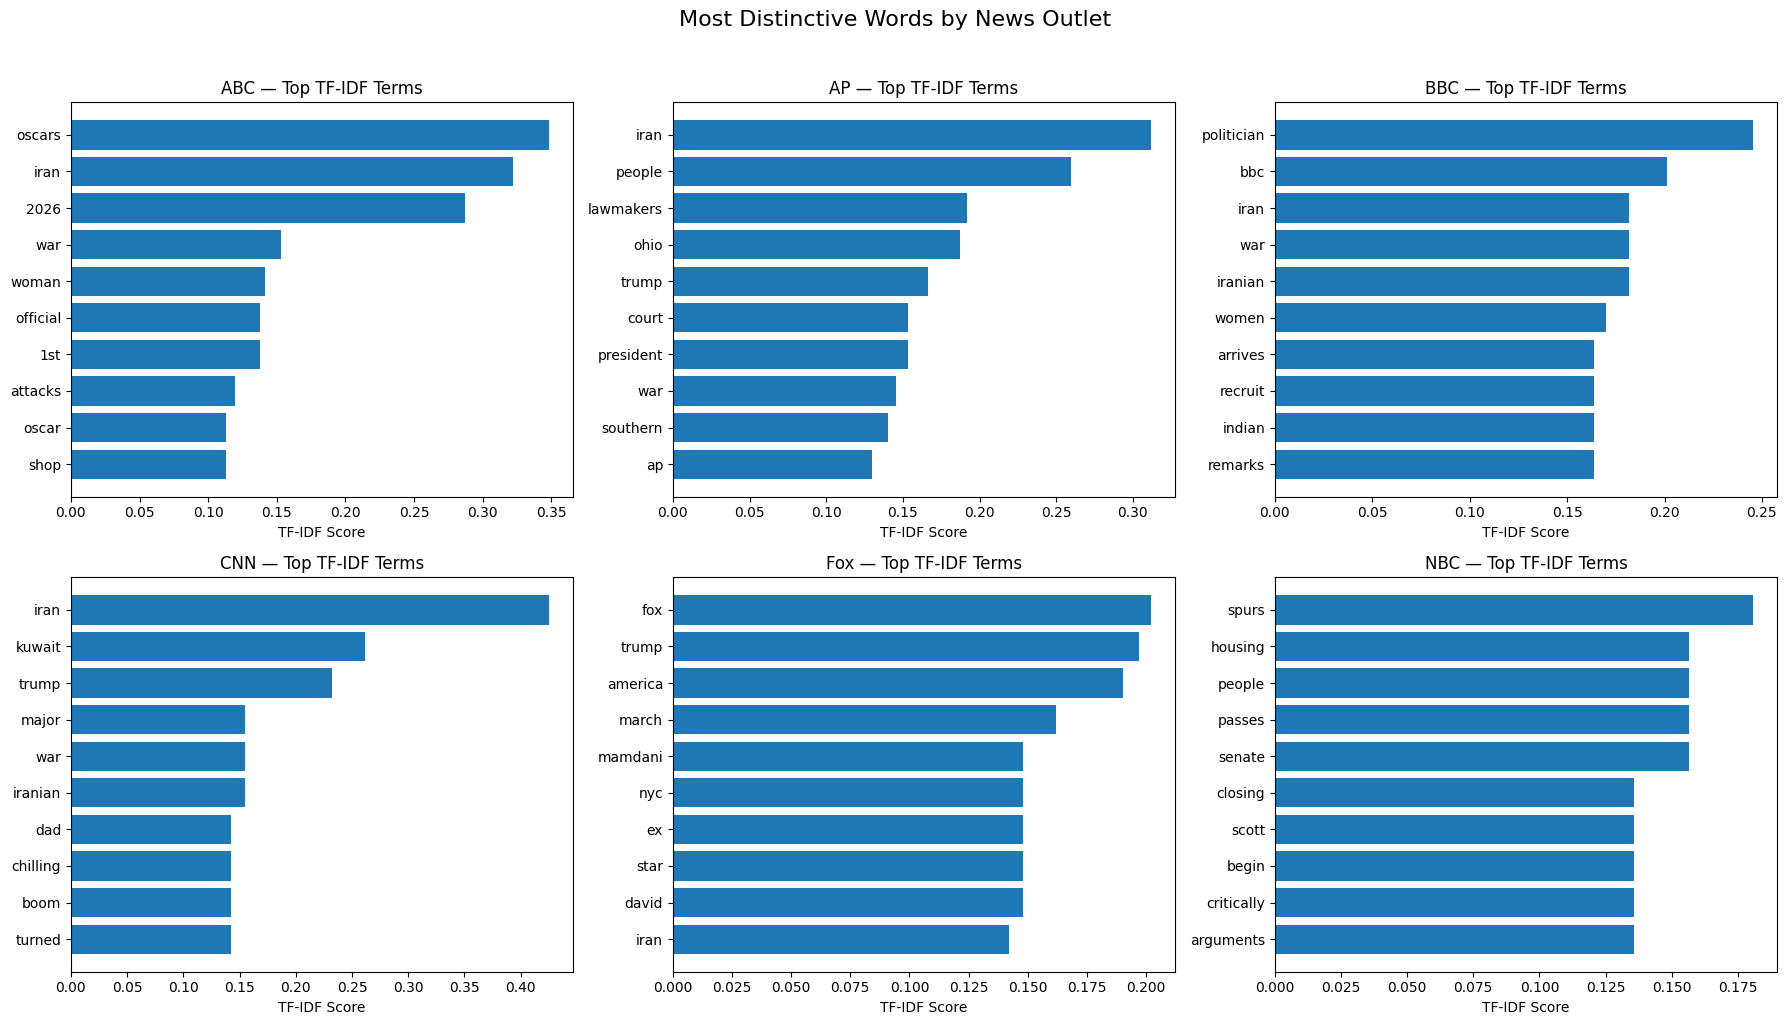

In [19]:
#plot the top words for each source using horizontal bar charts
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, row in source_docs.iterrows():
    source = row['Source']
    words = top_words(source, tfidf_matrix[i], feature_names, n=10)
    terms, scores = zip(*words)
    
    axes[i].barh(terms[::-1], scores[::-1])
    axes[i].set_title(f"{source} — Top TF-IDF Terms")
    axes[i].set_xlabel("TF-IDF Score")

plt.suptitle("Most Distinctive Words by News Outlet", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

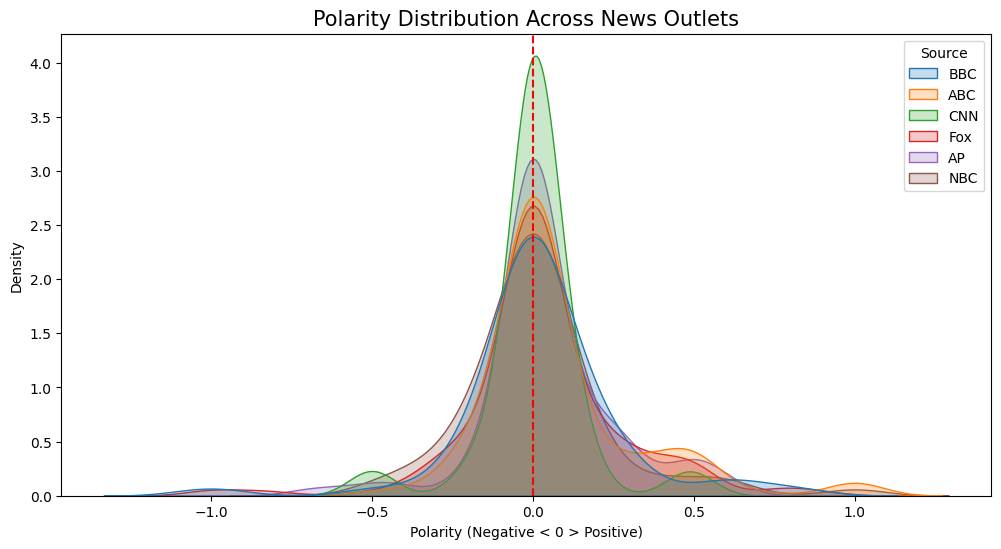

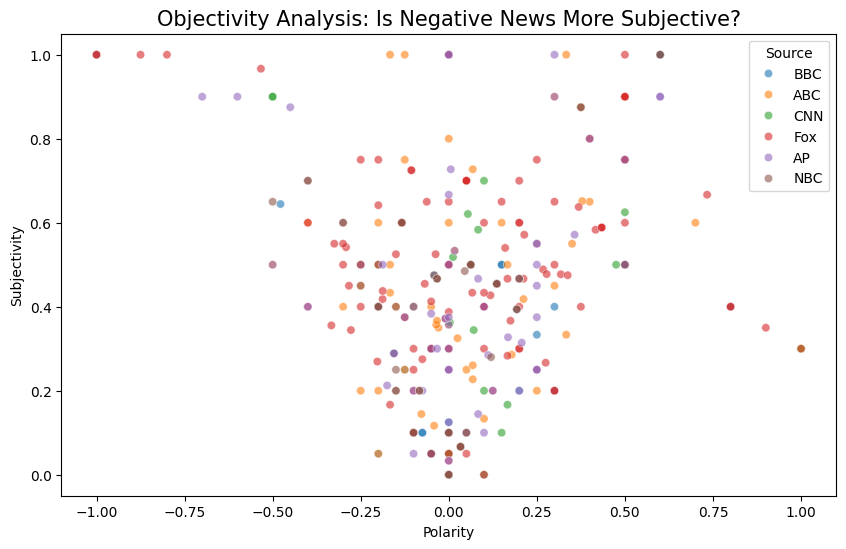

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Figure 1: Comparative Sentiment Distribution
sns.kdeplot(data=df, x="Polarity", hue="Source", fill=True, common_norm=False)
plt.title("Polarity Distribution Across News Outlets", fontsize=15)
plt.axvline(0, color='red', linestyle='--') # Mark the neutral line
plt.xlabel("Polarity (Negative < 0 > Positive)")
plt.show()

# Figure 2: Subjectivity vs Polarity (Research Question)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Polarity", y="Subjectivity", hue="Source", alpha=0.6)
plt.title("Objectivity Analysis: Is Negative News More Subjective?", fontsize=15)
plt.show()

In the above plot, I see a pretty random scatter with no obvious pattern. Negative headlines(left side) would need to be higher up to be able to say that negative news is more subjective, which it isn't.

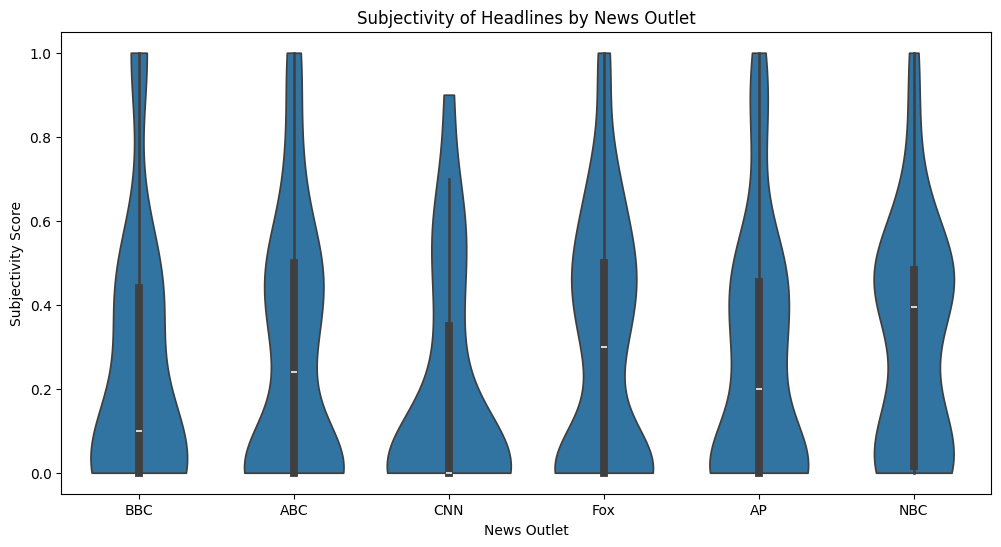

In [21]:
# Violin Plot

plt.figure(figsize = (12, 6))
sns.violinplot(data=df, x = "Source", y = "Subjectivity", cut = 0)
plt.title("Subjectivity of Headlines by News Outlet")
plt.xlabel("News Outlet")
plt.ylabel("Subjectivity Score")
plt.show()

The violin plot shows that all six outlets have similar subjectivity distributions, with most headlines clustering near 0, suggesting generally factual headlines. AP and ABC appear slightly wider at 0, which indicates a higher concentration of factual headlines. On the other hand, BBC shows a very slightly wider spread where subjectivity is 1 compared to the others. The differences are subtle, which aligns with the Kruskal-Wallis test finding that while statistically significant, the differences in subjectivity scores across news outlets are small.

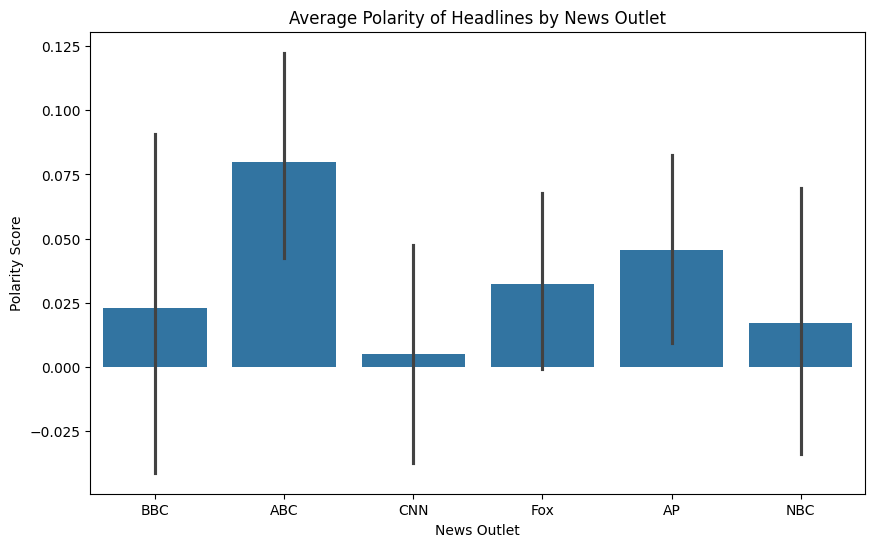

In [22]:
# Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Source", y="Polarity")
plt.title("Average Polarity of Headlines by News Outlet")
plt.xlabel("News Outlet")
plt.ylabel("Polarity Score")
plt.show()

The blue bar is the average polarity for the news outlet. The black line is the 95% confidence interval (which is default with seaborn) of the average polarity. It shows the range for where the true mean for the polarity likely falls. A longer black line indicates less certainity of where the true mean falls, because data may have been more scattered, while a shorter black line, like AP and ABC shows that the the polarity scores are more consistent. CNN has the highest average polarity, which suggests its headlines lean more positive, while AP shows the lowest average polarity, indicating a more netural or slightly negative language. 

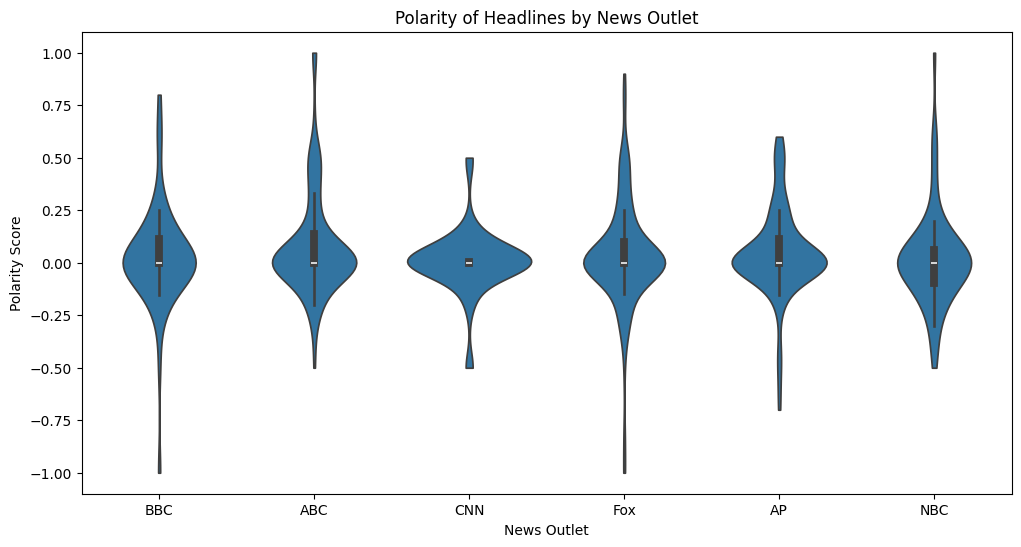

In [23]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="Source", y="Polarity", cut=0)
plt.title("Polarity of Headlines by News Outlet")
plt.xlabel("News Outlet")
plt.ylabel("Polarity Score")
plt.show()